# World Wrestling Entertainment (WWE) is an American professional wrestling promotion company

In [1]:
import matplotlib.pyplot as plt
import duckdb
import pandas as pd

In [2]:
conn = duckdb.connect("/Users/marietolteca/Documents/MEDS/WWE-database/wwe_database.db")
cur = conn.cursor()

In [ ]:
# cur.execute("""
#     SELECT s.superstar_name, YEAR(m.Date) AS Year, SUM(m.CageMatchRatingVotes) AS TotalVotes
#     FROM superstars s
#     JOIN match_rating m ON s.MatchIndex = m.Index
#     JOIN events e ON e.Date = m.Date AND e.Promotion = m.Promotion
#     WHERE e.Event = 'WWE WrestleMania'
#     AND s.superstar_name ILIKE '%cena%'
#     GROUP BY s.superstar_name, Year
#     ORDER BY Year DESC;
# """)

In [3]:
cur.execute("""
            SELECT 
            s.superstar_name,
            YEAR(m.Date) AS Year,
            SUM(m.CageMatchRatingVotes) AS TotalVotes
            FROM superstars s
            JOIN match_rating m ON s.MatchIndex = m.Index
            JOIN events e ON e.Date = m.Date AND e.Promotion = m.Promotion
            WHERE e.Event = 'WWE WrestleMania'
            GROUP BY s.superstar_name, Year
            ORDER BY TotalVotes DESC
            LIMIT 20;
""")

In [ ]:
#cur.df()         # pandas DataFrame ← best for analysis

In [4]:
# Save query from all superstars in Wrestlemania with most viewed total votes
superstar_wm = cur.df()

# Print the first five rows
superstar_wm

,superstar_name,Year,TotalVotes
0,Seth Rollins,2015,2278.0
1,Kofi Kingston,2019,1422.0
2,Daniel Bryan,2019,1422.0
3,Brock Lesnar,2015,1368.0
4,Roman Reigns,2015,1368.0
5,Drew McIntyre,2023,1327.0
6,Gunther,2023,1327.0
7,Sheamus,2023,1327.0
8,Rhea Ripley,2025,1269.0
9,Bianca Belair,2025,1269.0


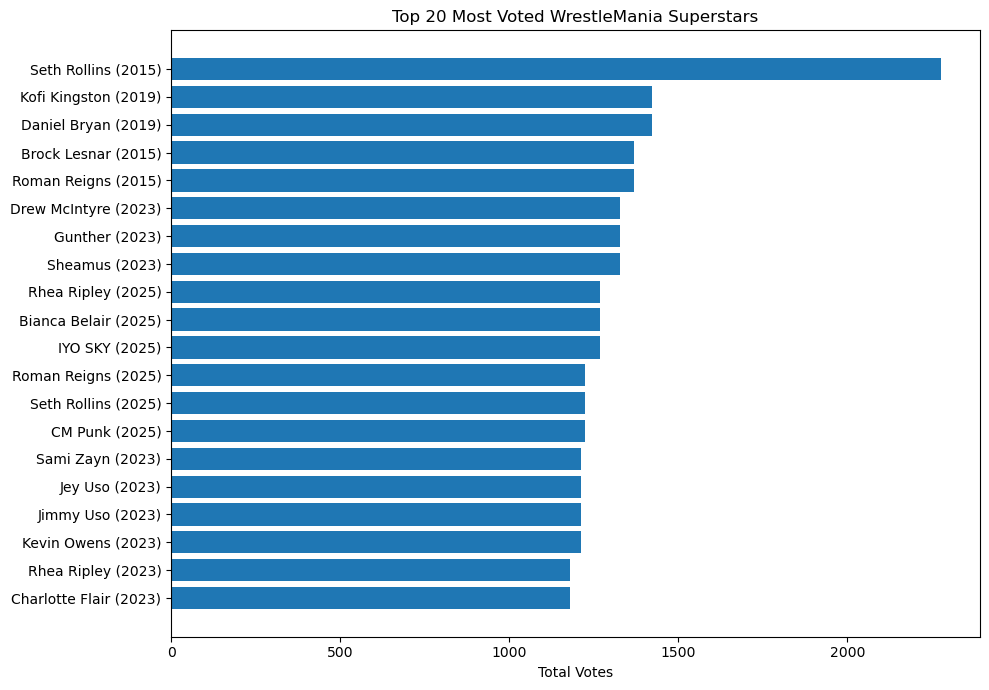

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(superstar_wm["superstar_name"] + " (" + superstar_wm["Year"].astype(str) + ")", superstar_wm["TotalVotes"])
ax.set_xlabel("Total Votes")
ax.set_title("Top 20 Most Voted WrestleMania Superstars")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

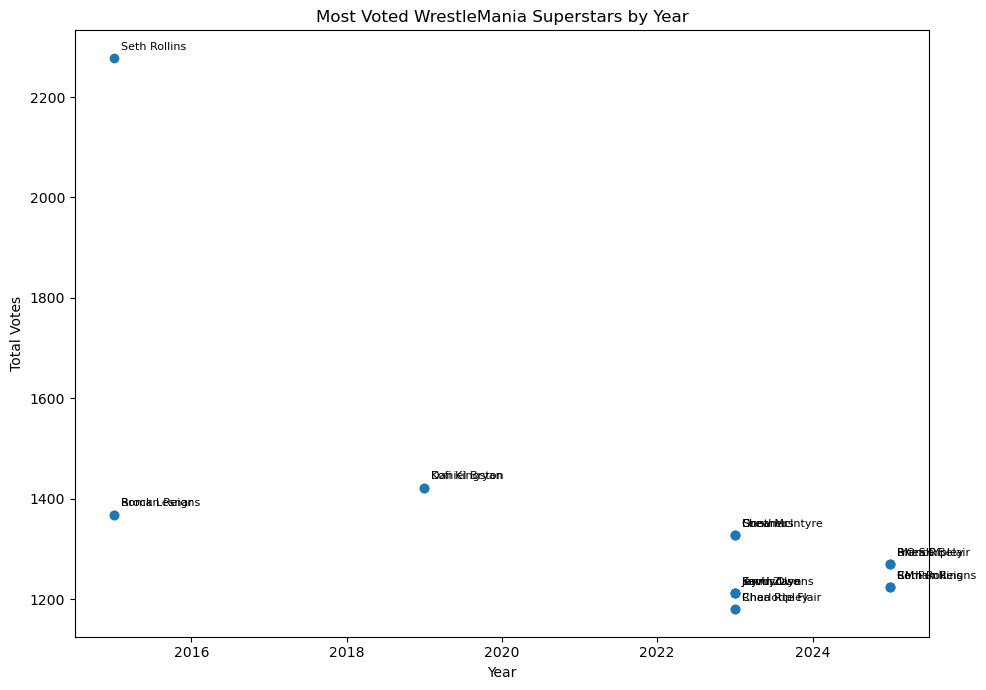

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(superstar_wm["Year"], superstar_wm["TotalVotes"])

for _, row in superstar_wm.iterrows():
    ax.annotate(row["superstar_name"], (row["Year"], row["TotalVotes"]),
                fontsize=8, textcoords="offset points", xytext=(5, 6))

ax.set_xlabel("Year")
ax.set_ylabel("Total Votes")
ax.set_title("Most Voted WrestleMania Superstars by Year")
plt.tight_layout()
plt.show()